# ODE Adjoint Optimization of Continuous Learning Dynamics
This notebook demonstrates how to use the highly optimized `ODEAdjointOptimizer` to find the worst-case payoff matrices for continuous learning dynamics. 
By utilizing the PyTorch Adjoint method, we avoid caching massive forward trajectories in VRAM, allowing us to optimize over thousands of steps efficiently!

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.engine.ode_optimizer import ODEAdjointOptimizer
from src.config.schemas import ExperimentConfig, GameConfig, DynamicConfig, ExecutionConfig
from src.engine.runner import ExperimentRunner
from src.utils.visualization import plot_static_trajectories
from src.engine.statistics import unpack_stats, load_experiment_stats

torch.set_default_dtype(torch.float64)


## 1. Configure the ODE Optimizer
We will configure the optimizer to use the 'envelope_trend' objective to maximize Player 1's outward limit cycles.
The solver uses fixed-step `rk4` to match our discrete simulation exact physics, and automatically performs multiple random restarts to escape local minima.

In [2]:
# Configuration for the ODE
ACTION_SIZE = 2  # 3x3 game
eta = 0.05
N_steps = 20000

optimizer = ODEAdjointOptimizer(
    action_sizes=[ACTION_SIZE, ACTION_SIZE],
    # eta=eta,
    N_steps=N_steps,
    projection_mode="tanh",           # Optimizes unconstrained weights and projects to [-1, 1] via tanh
    lr=0.01,                         # Adam learning rate
    # logit_penalty_threshold=12.0,     # Penalizes boundary-hugging to avoid float collapse
    # logit_penalty_weight=10.0,
    objective_type="raw",  # Maximize the growth of the regret envelope
    # T1_ratio=0.8,                     # Measures trend between the 60%-80% and 80%-100% time windows
    # lambda_reg=1.0,
    gamma_volatility=ACTION_SIZE,          # Adds a tie-breaking volatility score
    ode_method="midpoint"              # 2x faster than rk4
)


## 2. Run the Optimization
Run the Adam optimizer loop with Adjoint backpropagation over a few restarts to find the most pathological game possible!

In [3]:
# Run the optimization!
# We use a small number of epochs and restarts here for speed, but you can increase these for a deeper search.
best_payoffs, loss_history, penalty_history, final_states, final_t = optimizer.optimize(
    epochs=20,
    num_restarts=2,
    seed=42
)




Output()

In [5]:
print("Optimization Complete!")
print("\nWorst-case Payoff Matrix Player 1:")
print(np.round(best_payoffs[0].cpu().numpy(), 4))
print("\nWorst-case Payoff Matrix Player 2:")
print(np.round(best_payoffs[1].cpu().numpy(), 4))

Optimization Complete!

Worst-case Payoff Matrix Player 1:
[[-0.014  -0.1734]
 [ 0.0109 -0.0956]]

Worst-case Payoff Matrix Player 2:
[[-0.0436  0.0985]
 [-0.0346  0.1971]]


## 3. Verify in Discrete Engine
Now that we have discovered a pathological game using the Continuous ODE, let's inject it into our highly-optimized discrete-time `ExperimentRunner` and plot the resulting trajectories.

In [7]:
# Build a standard config for the runner
config = ExperimentConfig(
    name="ode_worst_case",
    game=GameConfig(
        num_players=2,
        action_sizes=[ACTION_SIZE, ACTION_SIZE],
        generator="custom",
        payoffs=[p.cpu().numpy().tolist() for p in best_payoffs]
    ),
    dynamic=DynamicConfig(
        algorithm="omwu",
        eta=eta,
        initial_strategy_type="uniform",
        logit_penalty_threshold=12.0,
        logit_penalty_norm=2,
        logit_penalty_mode="centered"
    ),
    execution=ExecutionConfig(
        total_steps=100000,           # Run for a much longer horizon!
        device="cuda" if torch.cuda.is_available() else "cpu",
        compile=True,
        steps_per_call=200,
        dtype="float64",
        batch_size=1,
        quiet=False
    )
)

# Run the discrete simulation
runner = ExperimentRunner(config)
summary = runner.run()
print(f"\nDiscrete Simulation Complete! Trajectory saved to: {summary['output_dir']}")


[09/04/26 11:06:34] INFO     Enabling PyTorch JIT compilation via torch.compile(backend='cudagraphs')...

                    INFO     Starting simulation 'ode_worst_case' [Session: 7314248b-4776-4968-99d7-7728eceb6385]  
                             on device 'cuda' for T=100000 steps.

Output()

[09/04/26 11:07:26] INFO     Simulation completed cleanly! Final Max Avg Regret: 0.000139. Stats session ID        
                             '7314248b-4776-4968-99d7-7728eceb6385' in 'outputs'


Discrete Simulation Complete! Trajectory saved to: outputs


## 4. Plot the Limit Cycles
Load the tracked statistics and visualize the beautiful limit cycles diverging outward over time!

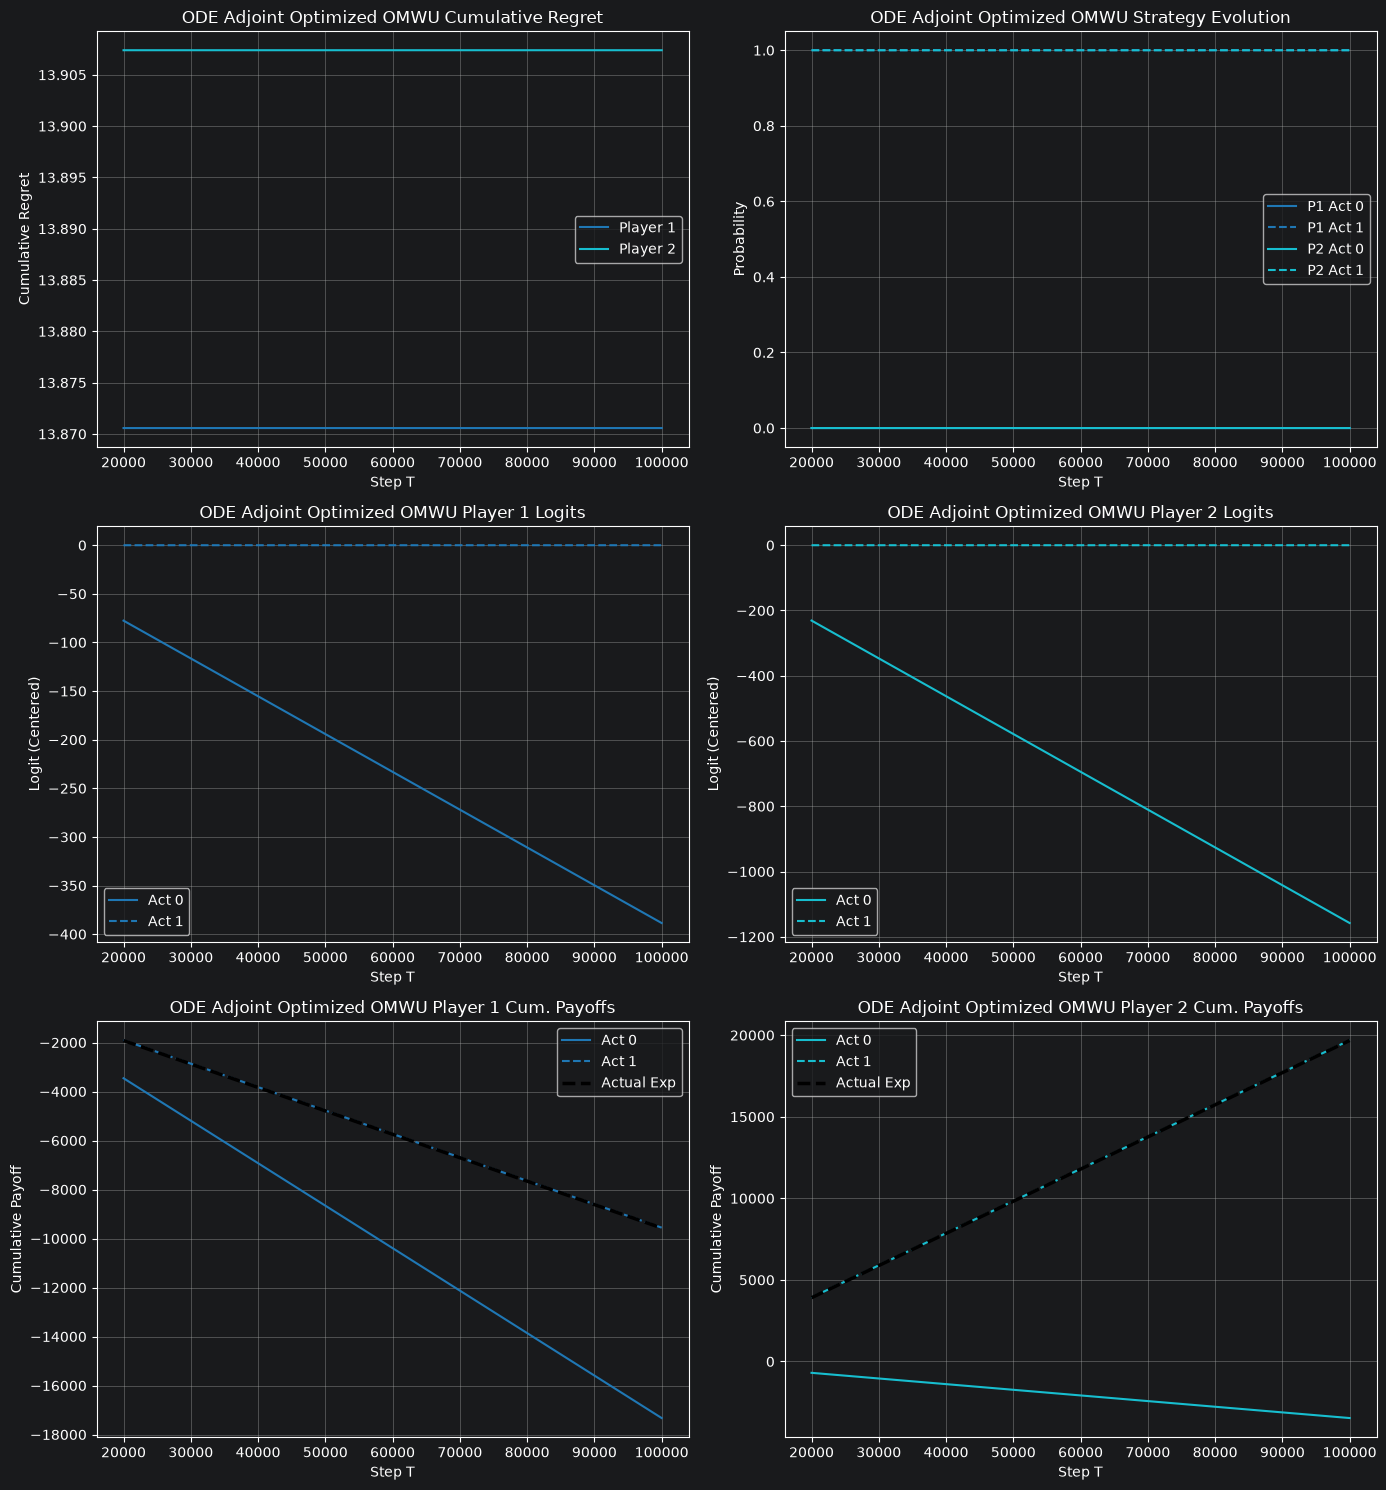

In [8]:
# Load statistics
stats_data = load_experiment_stats(output_dir=summary['output_dir'], session_id=summary['session_id'])
steps, cum_regrets, strats, logits, instant_payoffs = unpack_stats(stats_data)

# Calculate payoffs over time
cum_action_payoffs = [torch.cumsum(p, dim=0) for p in instant_payoffs]
cum_expected_payoffs = [torch.cumsum(torch.sum(s * p, dim=-1), dim=0) for s, p in zip(strats, instant_payoffs)]

# Plot!
fig, axes = plot_static_trajectories(
    steps, 
    cum_regrets, 
    strats, 
    title_prefix="ODE Adjoint Optimized OMWU", 
    plot_all_actions=True, 
    start_step=20000, 
    end_step=None, 
    cum_action_payoffs=cum_action_payoffs, 
    cum_expected_payoffs=cum_expected_payoffs, 
    logits=logits
)
plt.show()
